# 09 — Grounded QA Evaluation

Evaluation has two complementary layers:

1. **Deterministic metrics**
   - Citation validity
   - Evidence precision / recall / F1
   - Retrieval evidence recall
   - QA latency, tokens, cost

2. **LLM-as-a-Judge**
   - Correctness
   - Relevance
   - Completeness
   - Groundedness
   - Instruction following
   - Safety

The judge evaluates answer quality **only from retrieved comments**.
Judge latency/cost is reported separately because it is offline
evaluation overhead, not production QA latency.

Core logic lives in `src/rag/evaluation/`.

In [2]:
from pathlib import Path
import sys
import os
import json

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.rag.config import load_config
from src.rag.preprocessing.processor import TextProcessor
from src.rag.embedding.factory import EmbeddingFactory
from src.rag.vector_store.faiss import FAISSVectorStore
from src.rag.retrieval.embedding import EmbeddingRetriever
from src.rag.retrieval.bm25 import BM25Retriever
from src.rag.retrieval.hybrid import HybridRetriever

from src.rag.generation import OpenAIJSONGenerator
from src.rag.pipeline import GroundedQAPipeline

from src.rag.evaluation.dataset import EvaluationDataset
from src.rag.evaluation.qa_judge import QAJudge
from src.rag.evaluation.qa_evaluator import (
    QAEvaluator,
    format_qa_summary,
)

load_dotenv()

True

In [3]:
RAG_CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "rag.yaml"
)

QA_CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "qa.yaml"
)

EVAL_CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "qa_evaluation.yaml"
)

FAISS_PATH = (
    PROJECT_ROOT
    / "data"
    / "indexes"
    / "product_comments_embedding"
)

BM25_PATH = (
    PROJECT_ROOT
    / "data"
    / "indexes"
    / "product_comments_bm25_tantivy"
)

DATASET_PATH = (
    PROJECT_ROOT
    / "data"
    / "evaluation"
    / "retrieval_queries.json"
)

CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "data"
    / "evaluation"
    / "qa_eval_results.jsonl"
)

SUMMARY_PATH = (
    PROJECT_ROOT
    / "data"
    / "evaluation"
    / "qa_eval_summary.json"
)

RESULTS_CSV_PATH = (
    PROJECT_ROOT
    / "data"
    / "evaluation"
    / "qa_eval_results.csv"
)

rag_config = load_config(
    RAG_CONFIG_PATH
)

qa_config = load_config(
    QA_CONFIG_PATH
)

eval_config = load_config(
    EVAL_CONFIG_PATH
)

## Load the production retrieval + QA stack

In [4]:
processor = TextProcessor()

embedding_model = (
    EmbeddingFactory.create(
        provider=rag_config[
            "embedding"
        ]["provider"],
        model_name=rag_config[
            "embedding"
        ]["model"],
    )
)

vector_store = FAISSVectorStore()
vector_store.load(
    FAISS_PATH
)

embedding_retriever = (
    EmbeddingRetriever(
        embedding_model=embedding_model,
        processor=processor,
        vector_store=vector_store,
    )
)

bm25_retriever = (
    BM25Retriever(
        processor=processor
    )
)
bm25_retriever.load(
    BM25_PATH
)

hybrid_config = (
    rag_config[
        "retrieval"
    ]["hybrid"]
)

hybrid_retriever = (
    HybridRetriever(
        bm25_retriever=bm25_retriever,
        embedding_retriever=embedding_retriever,
        bm25_weight=hybrid_config[
            "bm25_weight"
        ],
        embedding_weight=hybrid_config[
            "embedding_weight"
        ],
    )
)

Loading weights: 100%|████████████████████| 199/199 [00:00<00:00, 17214.59it/s]


In [5]:
qa_generator = OpenAIJSONGenerator(
    api_key=os.getenv(
        "METIS_API_KEY"
    ),
    base_url=os.getenv(
        "METIS_BASE_URL"
    ),
    model=qa_config[
        "generation"
    ]["model"],
    input_cost_per_million=(
        qa_config[
            "generation"
        ].get(
            "input_cost_per_million"
        )
    ),
    output_cost_per_million=(
        qa_config[
            "generation"
        ].get(
            "output_cost_per_million"
        )
    ),
)

qa_pipeline = GroundedQAPipeline(
    retriever=hybrid_retriever,
    generator=qa_generator,
    top_k=qa_config[
        "qa"
    ]["top_k"],
    max_context_chars=qa_config[
        "qa"
    ]["max_context_chars"],
    max_chars_per_comment=qa_config[
        "qa"
    ][
        "max_chars_per_comment"
    ],
)

## Create LLM-as-a-Judge

In [6]:
judge_config = eval_config[
    "judge"
]

judge_generator = OpenAIJSONGenerator(
    api_key=os.getenv(
        "METIS_API_KEY"
    ),
    base_url=os.getenv(
        "METIS_BASE_URL"
    ),
    model=judge_config[
        "model"
    ],
    input_cost_per_million=(
        judge_config.get(
            "input_cost_per_million"
        )
    ),
    output_cost_per_million=(
        judge_config.get(
            "output_cost_per_million"
        )
    ),
)

judge = QAJudge(
    generator=judge_generator,
    max_context_chars=judge_config[
        "max_context_chars"
    ],
    max_chars_per_comment=judge_config[
        "max_chars_per_comment"
    ],
)

dataset = EvaluationDataset(
    DATASET_PATH
)

evaluator = QAEvaluator(
    qa_pipeline=qa_pipeline,
    judge=judge,
    dataset=dataset,
    weights=eval_config[
        "weights"
    ],
)

print(
    "Evaluation samples available:",
    len(dataset)
)

Evaluation samples available: 150


## Run evaluation

Default is 30 queries, sampled from different products when possible.

Results are checkpointed after every successful sample. Re-running
this cell does not pay for already completed samples.

In [7]:
run_config = eval_config[
    "evaluation"
]

summary, results = (
    evaluator.evaluate(
        output_path=CHECKPOINT_PATH,
        max_samples=run_config[
            "sample_size"
        ],
        one_query_per_product=run_config[
            "one_query_per_product"
        ],
        random_state=run_config[
            "random_state"
        ],
        resume=run_config[
            "resume"
        ],
    )
)

[1/30] sample=15 cached
[2/30] sample=76 cached
[3/30] sample=60 cached
[4/30] sample=149 cached
[5/30] sample=118 cached
[6/30] sample=81 cached
[7/30] sample=141 cached
[8/30] sample=136 cached
[9/30] sample=140 cached
[10/30] sample=53 cached
[11/30] sample=112 cached
[12/30] sample=93 cached
[13/30] sample=122 cached
[14/30] sample=70 cached
[15/30] sample=56 cached
[16/30] sample=21 refreshing invalid citation
[16/30] sample=21 score=5.00
[17/30] sample=12 cached
[18/30] sample=116 cached
[19/30] sample=89 cached
[20/30] sample=73 cached
[21/30] sample=104 cached
[22/30] sample=29 cached
[23/30] sample=85 cached
[24/30] sample=65 cached
[25/30] sample=78 cached
[26/30] sample=123 cached
[27/30] sample=50 cached
[28/30] sample=127 cached
[29/30] sample=96 cached
[30/30] sample=47 cached


## Final scorecard

In [8]:
print(
    format_qa_summary(
        summary
    )
)

GROUNDING QA EVALUATION

Samples:               30

Overall Score:         4.93 / 5

Correctness:           4.90
Relevance:             5.00
Completeness:          4.83
Groundedness:          4.93
Instruction Following: 4.97
Safety:                5.00

Citation Validity:     100.0%
Evidence Precision:    89.2%
Evidence Recall:       90.6%
Evidence F1:           86.9%
Retrieval Evidence R:  92.8%

Avg Latency:           2.75 sec
P50 Latency:           2.70 sec
P95 Latency:           3.68 sec
Avg Tokens:            765
Avg Cost:              N/A
Total QA Cost:         N/A

LLM-AS-A-JUDGE OVERHEAD
-----------------------
Avg Judge Latency:     10.77 sec
Avg Judge Tokens:      1515
Total Judge Cost:      N/A


## Save report artifacts

In [9]:
SUMMARY_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        summary,
        file,
        ensure_ascii=False,
        indent=2,
    )

results.to_csv(
    RESULTS_CSV_PATH,
    index=False,
)

print(
    "Summary:",
    SUMMARY_PATH
)

print(
    "Per-query CSV:",
    RESULTS_CSV_PATH
)

print(
    "Checkpoint:",
    CHECKPOINT_PATH
)

Summary: /home/ali/Desktop/projects/digikala-ai-assistant/data/evaluation/qa_eval_summary.json
Per-query CSV: /home/ali/Desktop/projects/digikala-ai-assistant/data/evaluation/qa_eval_results.csv
Checkpoint: /home/ali/Desktop/projects/digikala-ai-assistant/data/evaluation/qa_eval_results.jsonl


## Judge score breakdown

,mean_score
relevance,5.000000
safety,5.000000
instruction_following,4.966667
groundedness,4.933333
correctness,4.900000
completeness,4.833333


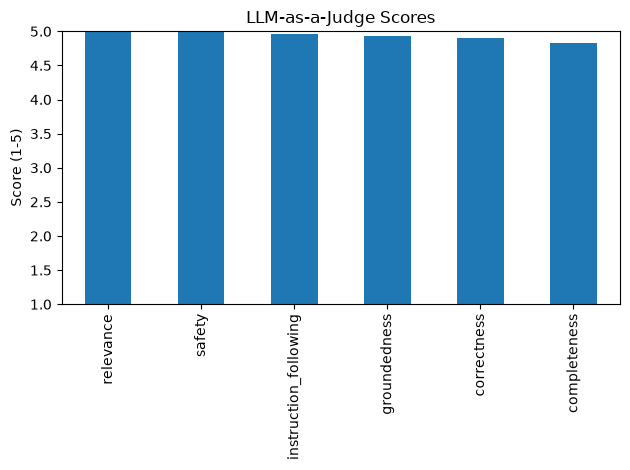

In [10]:
score_columns = [
    "correctness",
    "relevance",
    "completeness",
    "groundedness",
    "instruction_following",
    "safety",
]

judge_scores = (
    results[
        score_columns
    ]
    .mean()
    .sort_values(
        ascending=False
    )
)

display(
    judge_scores.to_frame(
        "mean_score"
    )
)

ax = judge_scores.plot(
    kind="bar",
    ylim=(1, 5),
    title="LLM-as-a-Judge Scores",
)

ax.set_ylabel(
    "Score (1-5)"
)

plt.tight_layout()
plt.show()

## Failure analysis

In [11]:
failures = (
    evaluator.failure_cases(
        results,
        n=10,
    )
)

display(
    failures
)

failure_counts = (
    pd.Series(
        [
            tag
            for tags
            in results[
                "failure_tags"
            ]
            for tag in tags
        ]
    )
    .value_counts()
)

display(
    failure_counts.to_frame(
        "count"
    )
)

,sample_idx,product_title,query,answer,overall_score,correctness,groundedness,evidence_precision,evidence_recall,failure_tags,judge_summary_reason
3,149,رنگ مو دوشس سری ترکیبی شماره 7.97 حجم 125 میلی...,رنگ نهایی این محصول شبیه عکس محصول است؟,خیر؛ طبق چند نظر، رنگ نهایی شبیه عکس یا آبیِ م...,4.50,4.0,4.0,0.25,1.0,"[overgeneralization, unsupported_claim]",پاسخ به‌خوبی نشان می‌دهد که طبق بیشتر تجربه‌ها...
21,29,پد پاک کننده ارایش میکاپ رز مدل soft بسته 92 عددی,آیا این پد برای مصرف تونر به‌صرفه است؟,بله؛ یک کاربر گفته این پد به‌دلیل جذب بهتر، در...,4.50,4.0,4.0,1.00,1.0,[unsupported_claim],پاسخ در اصل دقیق و مرتبط است و به‌درستی صرفه‌ج...
11,93,موتور گیربکس و چرخ مدل spidy کد 48,این موتور گیربکس برای ساخت ربات با آردوینو منا...,بله، طبق تجربه یک خریدار این موتور گیربکس‌دار ...,4.55,5.0,5.0,0.50,1.0,"[missed_key_evidence, ignores_conflict]",پاسخ دقیق، مرتبط و کاملاً مستند است، ولی برای ...
20,104,شورتکس زنانه کد 6672 مجموعه 3 عددی,آیا شورتکس مثل عکس کش دارد؟,خیر؛ یک خریدار گفته با اینکه در عکس کش دیده می...,4.60,4.0,5.0,1.00,1.0,[ignores_conflict],پاسخ بر صریح‌ترین شاهد تکیه دارد و به سؤال پاس...
6,141,جوراب ساق کوتاه مردانه لنتر مدل اسپرت SR- 06 م...,این جوراب‌ها از نظر دوام چقدر عمر می‌کنند؟,بر اساس یک تجربه مشخص، جوراب‌ها پس از حدود ۹ م...,4.85,5.0,5.0,0.50,1.0,[ignores_conflict],پاسخ دقیق و مستند است و بهترین شاهد مستقیم، یع...
18,89,ساختنی دکول مدل ۳۱۰۱۹,آیا با این ساختنی می‌توان مدل مک‌لارن سنا ساخت؟,بله؛ یکی از کاربران گفته با این ساختنی می‌توان...,4.85,5.0,5.0,1.00,0.5,[ignores_conflict],پاسخ مستقیماً و مستند به سؤال جواب می‌دهد؛ تنه...
0,15,کرم ژل آبرسان نوتروژینا مدل nemlendirme حجم 50...,آیا این کرم ژل برای پوست چرب مناسب است؟,بله؛ در چند تجربه، این کرم‌ژل برای پوست چرب من...,5.00,5.0,5.0,1.00,1.0,[],پاسخ دقیق، مرتبط و کاملاً مستند به دو تجربه مس...
1,76,قرص نصف کن اف تی ای کو مدل SPC,آیا این وسیله برای کپسول یا قرص‌های روکش‌دار ق...,خیر؛ طبق یک نظر، این وسیله برای کپسول و قرص‌ها...,5.00,5.0,5.0,1.00,1.0,[],پاسخ کوتاه، مرتبط و کاملاً منطبق با تنها نظر م...
2,60,کتاب راز اثر راندا برن انتشارات نگین ایران,آیا در پایان هر فصل کتاب، خلاصه نکات مهم آمده ...,بله؛ طبق نظر یکی از خریداران، پس از اتمام هر ف...,5.00,5.0,5.0,1.00,1.0,[],پاسخ کوتاه، مستقیم و کاملاً منطبق با تنها نظر ...
4,118,قندان مسی مس زنجان طرح انار مدل N75,آیا لبه‌های تاج انار تیز است و ممکن است دست را...,بله، طبق یک نظر، برش‌های تاج انار نیاز به پردا...,5.00,5.0,5.0,1.00,1.0,[],پاسخ کوتاه، دقیق و کاملاً مستند است و احتمال ب...


,count
ignores_conflict,4
unsupported_claim,2
overgeneralization,1
missed_key_evidence,1
